# rfm_data 파일 탐색


3519행 x 73열 , 126개 웨이퍼, 21종의fault 라벨, 20종은 의도적 결함 주입
 전체 구조

행(row): 한 웨이퍼 공정 중 일정 시간 간격으로 샘플링된 시계열 한 시점

웨이퍼당 약 30개 시점 (TIME ≈ 15초 ~ 110초)


열(column): TIME + 70개 RFM 센서 변수 + wafer_names + fault_name

=> 웨이퍼당 불규칙적인 시간 간격으로 측정되어 있다.
따라서 해당 시간간격을 일정하게 만들어 줄 필요가 있다.

In [2]:
# 라이브러리 불러오기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 (Colab용)
!apt-get -qq install fonts-nanum > /dev/null
import matplotlib.font_manager as fm
fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 로드
df = pd.read_csv('rfm_data.csv')

# fault_name의 trailing space 제거 (중요!)
df['fault_name'] = df['fault_name'].str.strip()
# wafer_names에서 .txt 제거하여 깔끔한 ID로
df['wafer_id'] = df['wafer_names'].str.replace('.txt', '', regex=False)

print(df.shape)
df.head()

(3519, 74)


,TIME,S1V1,S1V2,S1V3,S1V4,S1V5,S1I1,S1I2,S1I3,S1I4,...,S34V4,S34V5,S34I1,S34I2,S34I3,S34I4,S34I5,wafer_names,fault_name,wafer_id
0,15.32813,146.2126,7.474548,5.444838,2.468795,1.458764,2.651642,0.003891,0.002745,0.000811,...,2.695145,172.2877,14.99166,0.064546,0.018406,0.005021,0.004922,r2901.txt,calibration,r2901
1,18.45703,145.8764,7.500408,5.459276,2.465954,1.457085,2.657755,0.003940,0.002761,0.000817,...,2.687807,172.2852,14.92634,0.064253,0.017902,0.004927,0.004872,r2901.txt,calibration,r2901
2,21.58984,146.8875,7.413699,5.437320,2.437727,1.447055,2.633389,0.004037,0.002748,0.000815,...,2.691589,172.2836,14.92634,0.063929,0.017908,0.004853,0.004855,r2901.txt,calibration,r2901
3,24.71875,146.8875,7.372842,5.386851,2.432120,1.443727,2.636422,0.003990,0.002748,0.000817,...,2.695823,172.2836,14.91610,0.064036,0.017935,0.004829,0.004861,r2901.txt,calibration,r2901
4,27.84766,146.5498,7.357578,5.393677,2.423734,1.443727,2.636422,0.003954,0.002739,0.000815,...,2.697655,172.1836,14.92634,0.063893,0.017631,0.004860,0.004860,r2901.txt,calibration,r2901


In [3]:
print("=== 기본 정보 ===")
print(f"전체 행: {len(df):,}")
print(f"웨이퍼 수: {df['wafer_id'].nunique()}")
print(f"Fault 종류: {df['fault_name'].nunique()}")
print(f"결측치: {df.isnull().sum().sum()}")

print("\n=== Fault 분포 ===")
print(df['fault_name'].value_counts())

print("\n=== 웨이퍼당 시점 수 ===")
print(df.groupby('wafer_id').size().describe())

=== 기본 정보 ===
전체 행: 3,519
웨이퍼 수: 126
Fault 종류: 21
결측치: 0

=== Fault 분포 ===
fault_name
calibration    2963
Cl2 -10          30
Cl2 -5           30
TCP +50          29
He Chuck         29
TCP +10          28
Pr +3            28
RF +10           28
Pr -2            28
RF +8            28
TCP -15          28
TCP -20          28
TCP +30          28
BCl3 +10         28
RF -12           28
BCl3 +5          27
BCl3 -5          27
TCP +20          27
Cl2 +5           26
Pr +1            26
Pr +2            25
Name: count, dtype: int64

=== 웨이퍼당 시점 수 ===
count    126.000000
mean      27.928571
std        1.146672
min       25.000000
25%       27.000000
50%       28.000000
75%       28.000000
max       32.000000
dtype: float64


In [4]:
sensor_cols = [c for c in df.columns if c not in ['TIME','wafer_names','wafer_id','fault_name']]

# 카테고리별 분류 (정규식 기반)
import re
groups = {
    'S1_V': [c for c in sensor_cols if re.fullmatch(r'S1V\d', c)],
    'S1_I': [c for c in sensor_cols if re.fullmatch(r'S1I\d', c)],
    'S1_P': [c for c in sensor_cols if re.fullmatch(r'S1P\d', c)],
    'S2_V': [c for c in sensor_cols if re.fullmatch(r'S2V\d', c)],
    'S2_I': [c for c in sensor_cols if re.fullmatch(r'S2I\d', c)],
    'S2_P': [c for c in sensor_cols if re.fullmatch(r'S2P\d', c)],
    'S3_V': [c for c in sensor_cols if re.fullmatch(r'S3V\d', c)],
    'S3_I': [c for c in sensor_cols if re.fullmatch(r'S3I\d', c)],
    'S4_V': [c for c in sensor_cols if re.fullmatch(r'S4V\d', c)],
    'S4_I': [c for c in sensor_cols if re.fullmatch(r'S4I\d', c)],
    'S34_V': [c for c in sensor_cols if re.fullmatch(r'S34V\d', c)],
    'S34_I': [c for c in sensor_cols if re.fullmatch(r'S34I\d', c)],
    'S34P_V': [c for c in sensor_cols if re.fullmatch(r'S34PV\d', c)],
    'S34P_I': [c for c in sensor_cols if re.fullmatch(r'S34PI\d', c)],
}
for k, v in groups.items():
    print(f"{k}: {v}")

S1_V: ['S1V1', 'S1V2', 'S1V3', 'S1V4', 'S1V5']
S1_I: ['S1I1', 'S1I2', 'S1I3', 'S1I4', 'S1I5']
S1_P: ['S1P1', 'S1P2', 'S1P3', 'S1P4', 'S1P5']
S2_V: ['S2V1', 'S2V2', 'S2V3', 'S2V4', 'S2V5']
S2_I: ['S2I1', 'S2I2', 'S2I3', 'S2I4', 'S2I5']
S2_P: ['S2P1', 'S2P2', 'S2P3', 'S2P4', 'S2P5']
S3_V: ['S3V1', 'S3V2', 'S3V3', 'S3V4', 'S3V5']
S3_I: ['S3I1', 'S3I2', 'S3I3', 'S3I4', 'S3I5']
S4_V: ['S4V1', 'S4V2', 'S4V3', 'S4V4', 'S4V5']
S4_I: ['S4I1', 'S4I2', 'S4I3', 'S4I4', 'S4I5']
S34_V: ['S34V1', 'S34V2', 'S34V3', 'S34V4', 'S34V5']
S34_I: ['S34I1', 'S34I2', 'S34I3', 'S34I4', 'S34I5']
S34P_V: ['S34PV1', 'S34PV2', 'S34PV3', 'S34PV4', 'S34PV5']
S34P_I: ['S34PI1', 'S34PI2', 'S34PI3', 'S34PI4', 'S34PI5']


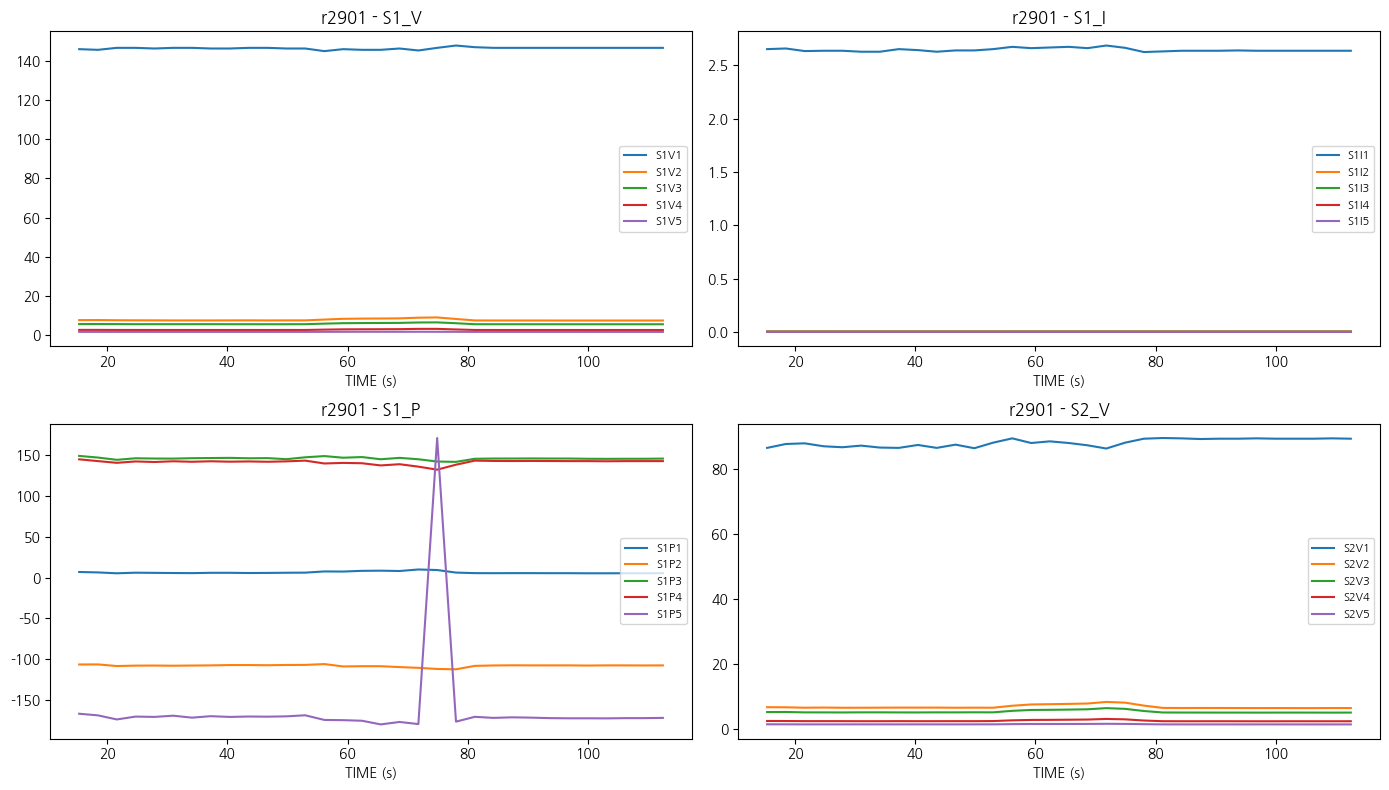

In [5]:
sample_wafer = 'r2901'  # 정상(calibration) 웨이퍼
sub = df[df['wafer_id'] == sample_wafer].sort_values('TIME')

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, (gname, cols) in zip(axes.ravel(), list(groups.items())[:4]):
    for c in cols:
        ax.plot(sub['TIME'], sub[c], label=c)
    ax.set_title(f"{sample_wafer} - {gname}")
    ax.set_xlabel('TIME (s)')
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

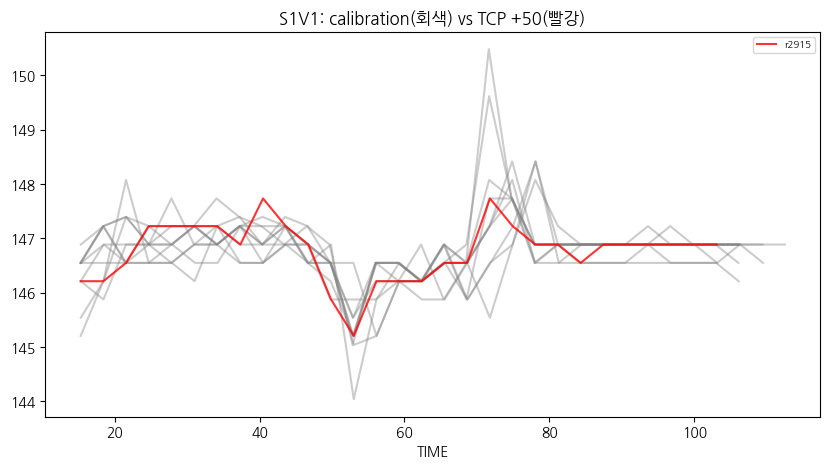

In [6]:
target_col = 'S1V1'  # 관심 변수
fault_pick = 'TCP +50'  # 결함 한 종류

fig, ax = plt.subplots(figsize=(10,5))
for wid in df[df['fault_name']=='calibration']['wafer_id'].unique()[:10]:
    s = df[df['wafer_id']==wid].sort_values('TIME')
    ax.plot(s['TIME'], s[target_col], color='gray', alpha=0.4)
for wid in df[df['fault_name']==fault_pick]['wafer_id'].unique():
    s = df[df['wafer_id']==wid].sort_values('TIME')
    ax.plot(s['TIME'], s[target_col], color='red', alpha=0.8, label=wid)
ax.set_title(f'{target_col}: calibration(회색) vs {fault_pick}(빨강)')
ax.set_xlabel('TIME'); ax.legend(fontsize=7)
plt.show()

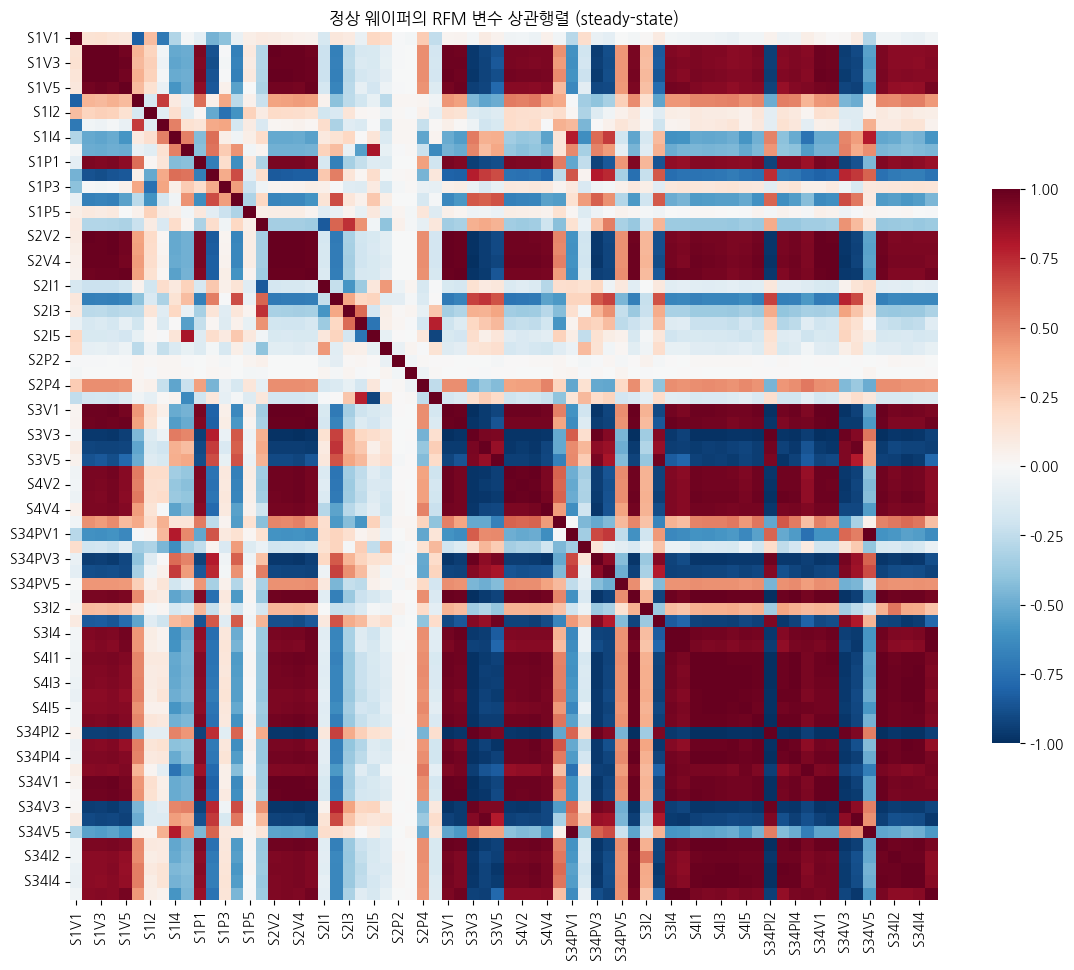

In [7]:
# steady-state만 사용 (TIME 30~90초 가정)
ss = df[(df['TIME']>=30) & (df['TIME']<=90) & (df['fault_name']=='calibration')]

corr = ss[sensor_cols].corr()
plt.figure(figsize=(14,12))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1, square=True, cbar_kws={'shrink':0.6})
plt.title('정상 웨이퍼의 RFM 변수 상관행렬 (steady-state)')
plt.show()

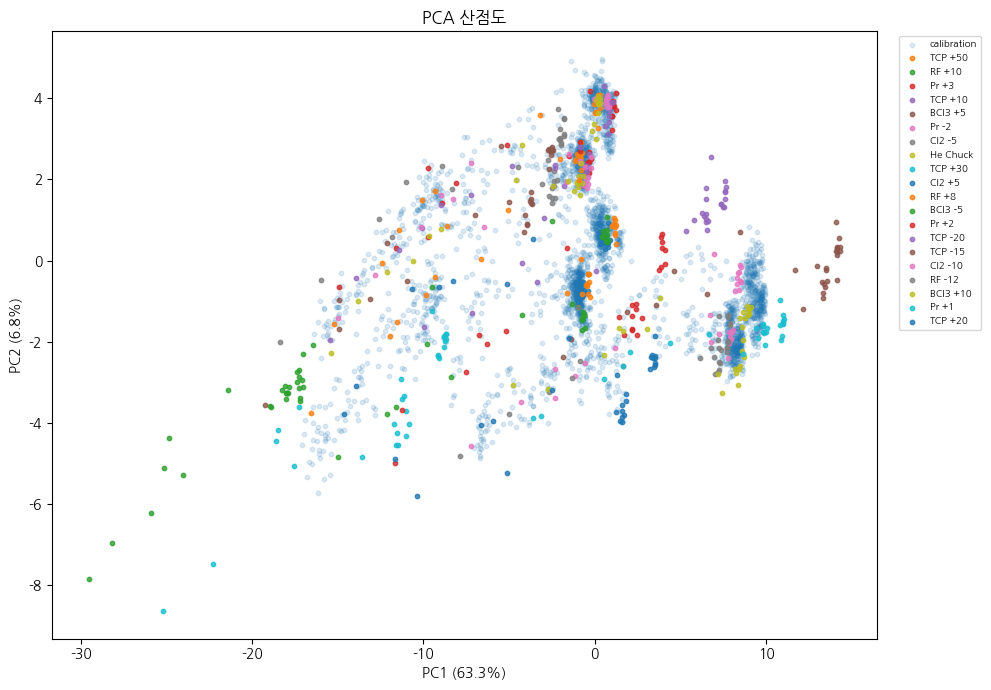

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[sensor_cols].values
y = df['fault_name'].values

Xs = StandardScaler().fit_transform(X)
pca = PCA(n_components=2).fit(Xs)
Z = pca.transform(Xs)

plt.figure(figsize=(10,7))
for f in df['fault_name'].unique():
    mask = y == f
    a = 0.15 if f=='calibration' else 0.8
    plt.scatter(Z[mask,0], Z[mask,1], s=10, alpha=a, label=f)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.legend(bbox_to_anchor=(1.02,1), fontsize=7)
plt.title('PCA 산점도'); plt.tight_layout(); plt.show()

In [9]:
def summarize_wafer(g):
    # steady-state 윈도우
    g_ss = g[(g['TIME']>=30) & (g['TIME']<=90)]
    feats = {}
    for c in sensor_cols:
        feats[f'{c}_mean']  = g_ss[c].mean()
        feats[f'{c}_std']   = g_ss[c].std()
        feats[f'{c}_min']   = g_ss[c].min()
        feats[f'{c}_max']   = g_ss[c].max()
        feats[f'{c}_slope'] = np.polyfit(g_ss['TIME'], g_ss[c], 1)[0] if len(g_ss)>=2 else 0
    feats['n_points']   = len(g)
    feats['fault_name'] = g['fault_name'].iloc[0]
    return pd.Series(feats)

wafer_df = df.groupby('wafer_id').apply(summarize_wafer).reset_index()
print(wafer_df.shape)
wafer_df.head()

(126, 353)


/tmp/ipykernel_8239/1701692853.py:15: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  wafer_df = df.groupby('wafer_id').apply(summarize_wafer).reset_index()


,wafer_id,S1V1_mean,S1V1_std,S1V1_min,S1V1_max,S1V1_slope,S1V2_mean,S1V2_std,S1V2_min,S1V2_max,...,S34I4_min,S34I4_max,S34I4_slope,S34I5_mean,S34I5_std,S34I5_min,S34I5_max,S34I5_slope,n_points,fault_name
0,r2901,146.577689,0.641823,145.2061,148.0761,0.004350,7.735709,0.545506,7.281735,8.844737,...,0.004802,0.007422,0.000013,0.004976,0.000142,0.004844,0.005171,2.204573e-06,32,calibration
1,r2903,146.587495,0.833021,144.0406,148.4174,0.010206,7.708138,0.547948,7.250783,8.890679,...,0.004771,0.007266,0.000007,0.004967,0.000148,0.004838,0.005192,1.553978e-06,31,calibration
2,r2904,146.551442,0.727017,145.0390,148.4174,0.008911,7.701958,0.545190,7.255794,8.875340,...,0.004797,0.007206,0.000009,0.004962,0.000152,0.004833,0.005192,1.945047e-06,31,calibration
3,r2905,146.719437,0.524357,145.2061,147.7356,0.002345,7.678884,0.542331,7.214977,8.742486,...,0.004734,0.007175,0.000005,0.004954,0.000152,0.004827,0.005165,9.221333e-07,30,calibration
4,r2906,146.764047,0.573040,145.2061,147.7356,0.003321,7.675904,0.533590,7.209995,8.732426,...,0.004734,0.007146,0.000005,0.004952,0.000154,0.004816,0.005165,7.069333e-07,30,calibration


In [10]:
print("명시적 결측치(NaN) 셀:", int(df.isna().sum().sum()))
print("완전 중복 행:", int(df.duplicated().sum()))

rl = df.groupby('wafer_names').size()
print(f"런별 샘플 수: 최소 {rl.min()} / 최대 {rl.max()} / 중앙값 {int(rl.median())}")

# 웨이퍼별 샘플링 간격 jitter (= '비균등'의 원인)
gaps = []
for _, g in df.groupby('wafer_names'):
    gaps.extend(np.diff(g['TIME'].values).tolist())
gaps = np.array(gaps)
print(f"샘플링 간격: 평균 {gaps.mean():.4f}s, 표준편차 {gaps.std():.4f}s, "
      f"범위 {gaps.min():.3f}~{gaps.max():.3f}s")

명시적 결측치(NaN) 셀: 0
완전 중복 행: 0
런별 샘플 수: 최소 25 / 최대 32 / 중앙값 28
샘플링 간격: 평균 3.1324s, 표준편차 0.0105s, 범위 3.066~3.191s


In [11]:
# 핵심: TIME은 웨이퍼마다 리셋되는 '공정 경과시간'이므로 웨이퍼별로 따로 리샘플링
DT = 3.13                       # 명목 샘플링 주기(초)
T0 = round(df['TIME'].min(), 2) # 공통 시작점 (~15.27s)

resampled = []
for name, g in df.groupby('wafer_names', sort=False):
    g = g.sort_values('TIME')
    t = g['TIME'].values
    grid = np.arange(T0, t.max() + 1e-9, DT)        # 균등 그리드
    out = {'TIME': np.round(grid, 4)}
    for c in sensor_cols:
        out[c] = np.interp(grid, t, g[c].values)    # 선형보간
    sub = pd.DataFrame(out)
    sub['wafer_names'] = name
    sub['fault_name']  = g['fault_name'].iloc[0]
    resampled.append(sub)

rs = pd.concat(resampled, ignore_index=True)

# 검증: 리샘플 후 간격 표준편차 ≈ 0
g2 = []
for _, g in rs.groupby('wafer_names'):
    g2.extend(np.diff(g['TIME'].values).tolist())
print("리샘플 후 형태:", rs.shape, "| 간격 표준편차:", round(np.std(g2), 6))

rs.to_csv('rfm_resampled_uniform.csv', index=False)

리샘플 후 형태: (3518, 73) | 간격 표준편차: 0.0


In [12]:
cal = rs[rs['fault_name'] == 'calibration']
mu  = cal[sensor_cols].mean()
sd  = cal[sensor_cols].std().replace(0, 1)

z = rs.copy()
z[sensor_cols] = (rs[sensor_cols] - mu) / sd
z.to_csv('rfm_resampled_zscore.csv', index=False)

calmask = z['fault_name'] == 'calibration'
print("z-score 변환 완료:", z.shape)

z-score 변환 완료: (3518, 73)


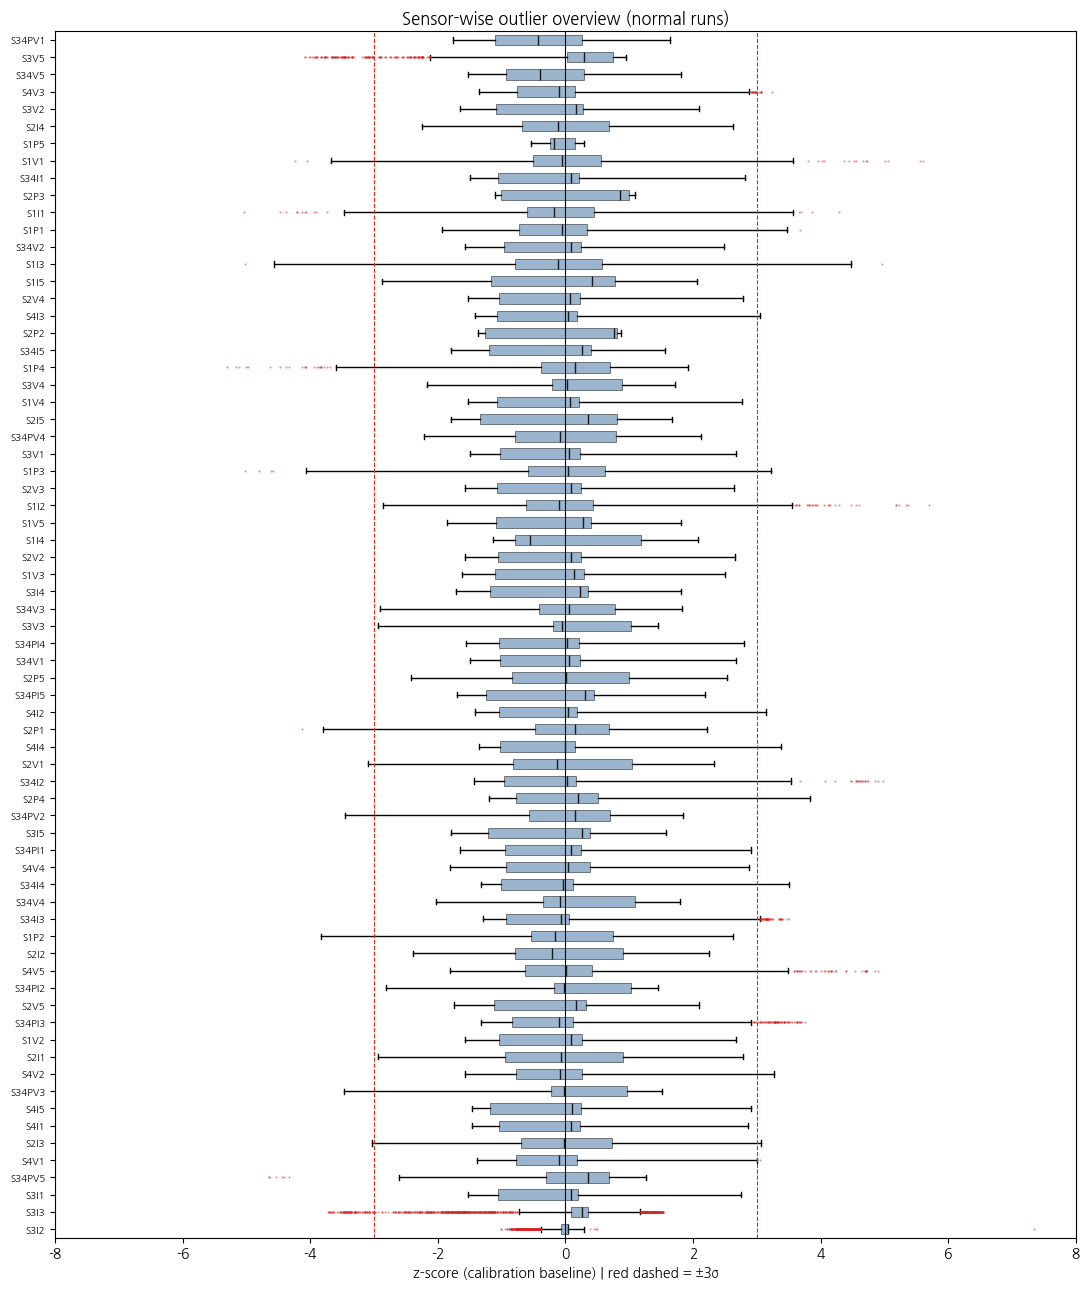

In [13]:
zc = z.loc[calmask, sensor_cols]
order = zc.std().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(11, 13))
bp = ax.boxplot([zc[c].values for c in order], vert=False, widths=0.6, whis=3.0,
                patch_artist=True,
                flierprops=dict(marker='.', ms=3, mfc='#d62728', mec='none', alpha=.5))
for b in bp['boxes']:   b.set(facecolor='#4c78a8', alpha=.55, lw=.6)
for m in bp['medians']: m.set(color='#1a1a1a', lw=1)

ax.set_yticks(range(1, len(order)+1)); ax.set_yticklabels(order, fontsize=7)
for x, c in [(0,'k'), (3,'#d62728'), (-3,'#d62728')]:
    ax.axvline(x, color=c, ls='--' if x else '-', lw=.8)
ax.set_xlim(-8, 8)
ax.set_xlabel('z-score (calibration baseline) | red dashed = ±3σ')
ax.set_title('Sensor-wise outlier overview (normal runs)')
plt.tight_layout(); plt.show()

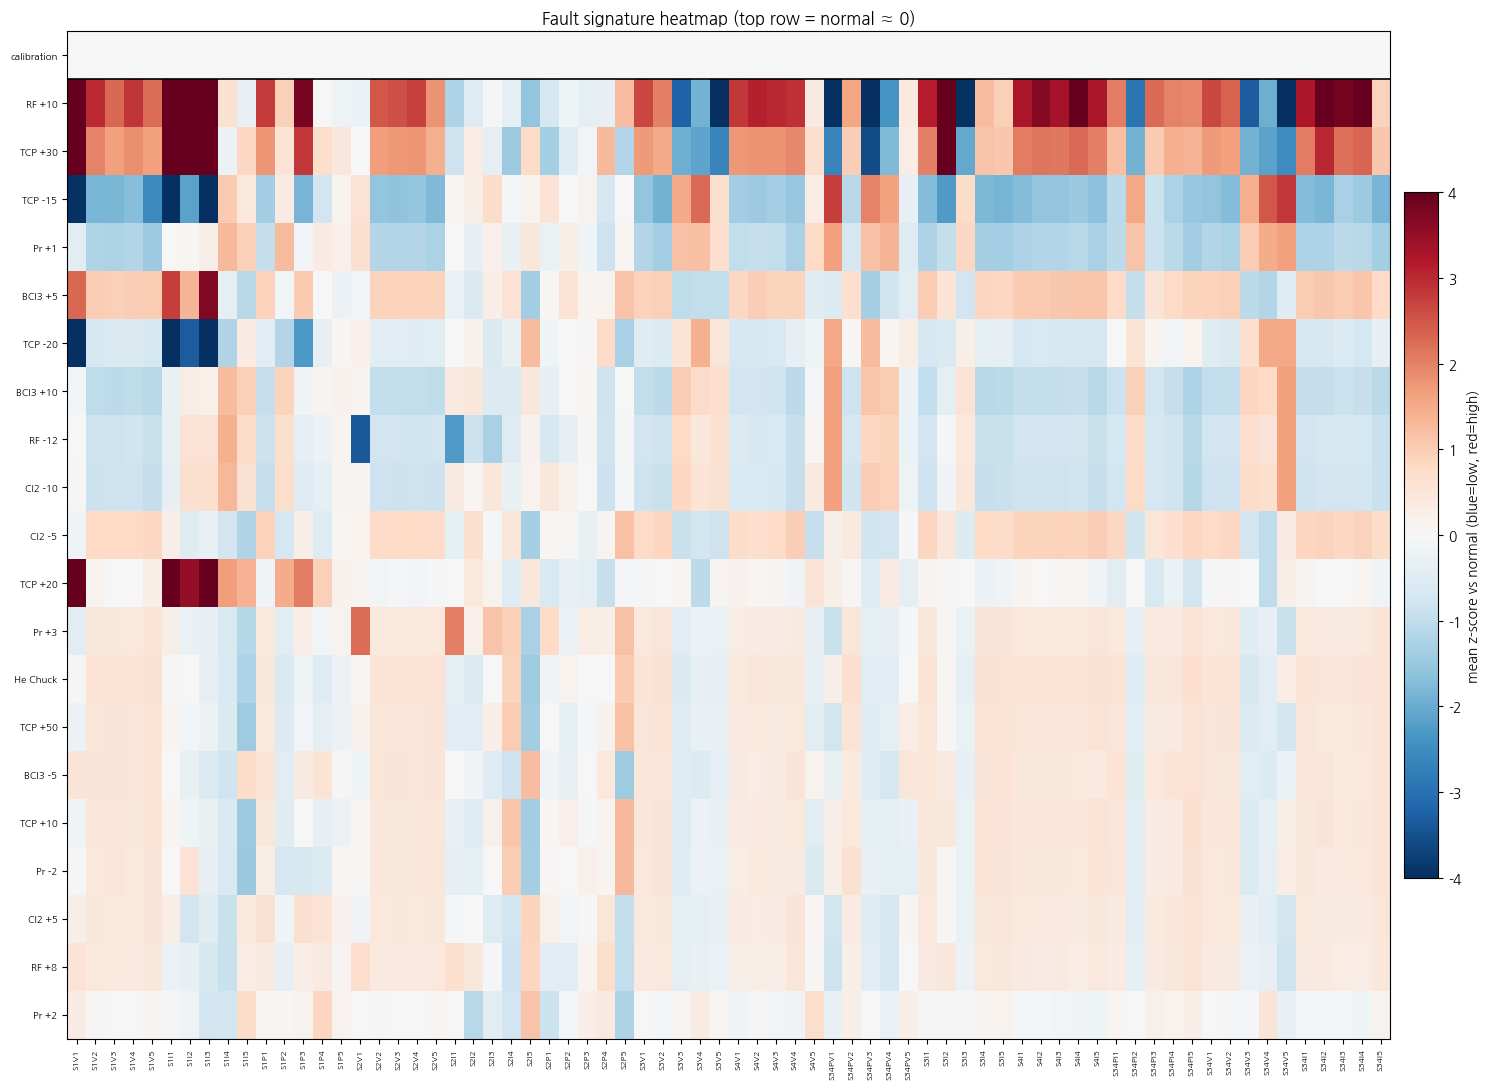

In [14]:
sig = z.groupby('fault_name')[sensor_cols].mean()
sig['_dev'] = sig.abs().mean(axis=1)
sig = pd.concat([sig.loc[['calibration']],
                 sig.drop('calibration').sort_values('_dev', ascending=False)])
order_dev = sig.index.tolist(); sig = sig.drop(columns='_dev')

fig, ax = plt.subplots(figsize=(15, 11))
im = ax.imshow(sig.values, aspect='auto', cmap='RdBu_r', vmin=-4, vmax=4)
ax.set_xticks(range(len(sensor_cols))); ax.set_xticklabels(sensor_cols, rotation=90, fontsize=6)
ax.set_yticks(range(len(order_dev)));   ax.set_yticklabels(order_dev, fontsize=7)
ax.axhline(0.5, color='k', lw=1.2)   # calibration 구분선
cb = plt.colorbar(im, fraction=0.025, pad=0.01)
cb.set_label('mean z-score vs normal (blue=low, red=high)')
ax.set_title('Fault signature heatmap (top row = normal ≈ 0)')
plt.tight_layout(); plt.show()

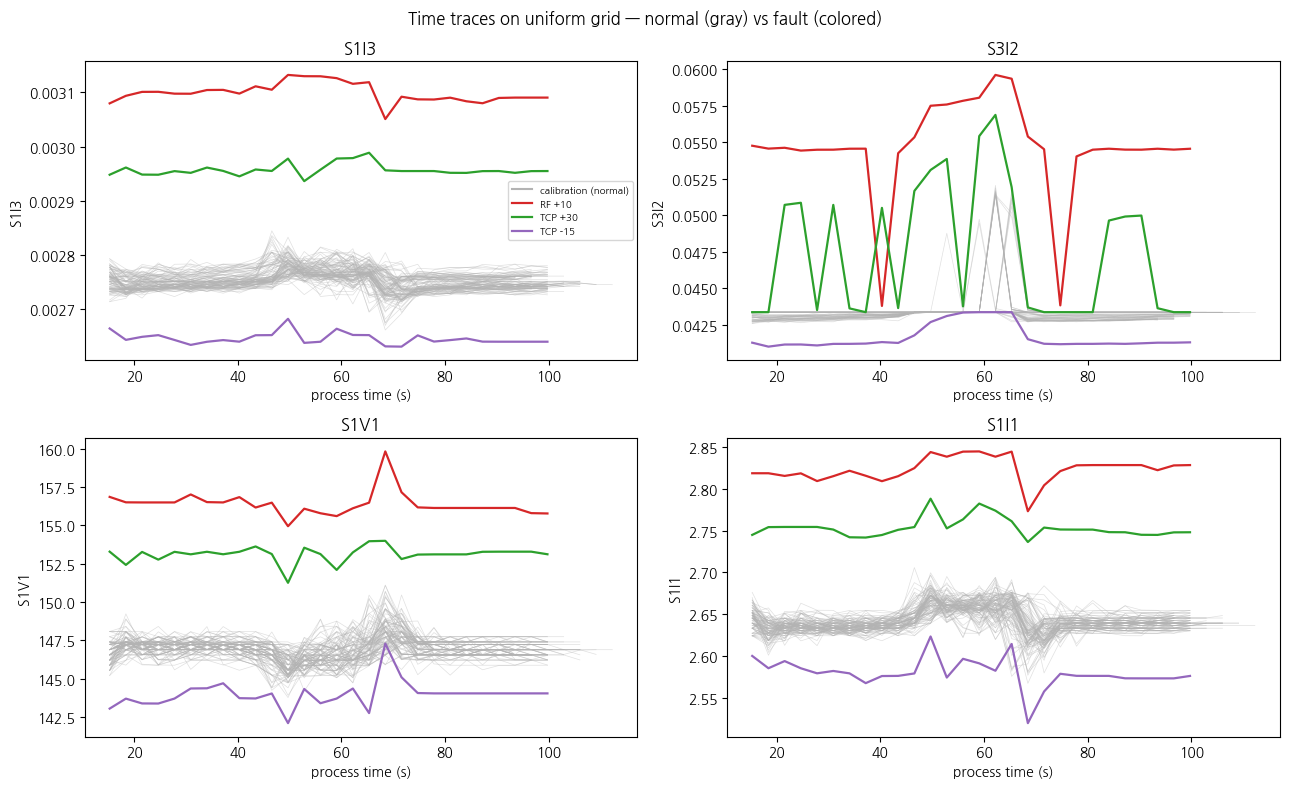

In [15]:
disc = sig.abs().max().sort_values(ascending=False).index[:4].tolist()
faults_show = sig.abs().mean(axis=1).drop('calibration').sort_values(ascending=False).index[:3].tolist()
colors = ['#d62728', '#2ca02c', '#9467bd']

fig, axes = plt.subplots(2, 2, figsize=(13, 8)); axes = axes.ravel()
for i, sc in enumerate(disc):
    ax = axes[i]
    for _, g in rs[rs['fault_name'] == 'calibration'].groupby('wafer_names'):
        ax.plot(g['TIME'], g[sc], color='0.7', lw=.5, alpha=.4)
    ax.plot([], [], color='0.7', lw=1.5, label='calibration (normal)')
    for f, col in zip(faults_show, colors):
        gg = rs[rs['fault_name'] == f]
        gg = gg[gg['wafer_names'] == gg['wafer_names'].iloc[0]]
        ax.plot(gg['TIME'], gg[sc], color=col, lw=1.6, label=f)
    ax.set_title(sc); ax.set_xlabel('process time (s)'); ax.set_ylabel(sc)
    if i == 0: ax.legend(fontsize=7)
fig.suptitle('Time traces on uniform grid — normal (gray) vs fault (colored)')
plt.tight_layout(); plt.show()

In [16]:
from google.colab import files
files.download('rfm_resampled_uniform.csv')
files.download('rfm_resampled_zscore.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**여기서부터는  
 위의 데이터 파일을 탐색으로부터 본격적 PCA 및  T²/Q  통계분석!**

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()   # rfm_data.csv 선택

plt.rcParams.update({'figure.dpi':120, 'font.size':9,
                     'axes.grid':True, 'grid.alpha':0.25})

df = pd.read_csv('rfm_data.csv')
sensor_cols = [c for c in df.columns if c not in ['TIME','wafer_names','fault_name']]
print("형태:", df.shape, "| 센서 수:", len(sensor_cols), "| 웨이퍼 수:", df['wafer_names'].nunique())

Saving rfm_data.csv to rfm_data (1).csv
형태: (3519, 73) | 센서 수: 70 | 웨이퍼 수: 126


In [18]:
K = 28   # 공통 시점 수 (런 길이 중앙값). 결과 보고 조정 가능

wafers, labels, blocks = [], [], []
grid = np.linspace(0, 1, K)                      # 공통 정규화 시간축

for name, g in df.groupby('wafer_names', sort=False):
    g = g.sort_values('TIME')
    t = g['TIME'].values
    tn = (t - t.min()) / (t.max() - t.min())     # 시간 0~1 정규화
    mat = np.column_stack([np.interp(grid, tn, g[c].values) for c in sensor_cols])  # (K, 70)
    blocks.append(mat)
    wafers.append(name)
    labels.append(g['fault_name'].iloc[0])

tensor = np.stack(blocks)                         # (126, K, 70)
label_s = pd.Series(labels, index=wafers, name='fault_name')

print("3D 텐서:", tensor.shape, "  (웨이퍼 x 시점 x 센서)")
print("정상 웨이퍼:", (label_s=='calibration').sum(), "| 이상 웨이퍼:", (label_s!='calibration').sum())

3D 텐서: (126, 28, 70)   (웨이퍼 x 시점 x 센서)
정상 웨이퍼: 106 | 이상 웨이퍼: 20


In [19]:
# 각 (시점, 센서) 조합을 하나의 컬럼으로: "센서_t시점"
feat_cols = [f"{s}_t{k:02d}" for k in range(K) for s in sensor_cols]
X = tensor.reshape(tensor.shape[0], -1)           # (126, K*70=1960)
X_df = pd.DataFrame(X, index=wafers, columns=feat_cols)
X_df.index.name = 'wafer_names'

print("펼친 행렬:", X_df.shape, " <- 웨이퍼 한 장 = 한 행")
print("이 형태가 나중에 OES/EV와 웨이퍼명 기준 가로 결합의 기준이 됩니다.")
X_df.iloc[:3, :5]

펼친 행렬: (126, 1960)  <- 웨이퍼 한 장 = 한 행
이 형태가 나중에 OES/EV와 웨이퍼명 기준 가로 결합의 기준이 됩니다.


,S1V1_t00,S1V2_t00,S1V3_t00,S1V4_t00,S1V5_t00
wafer_names,,,,,
r2901.txt,146.2126,7.474548,5.444838,2.468795,1.458764
r2903.txt,146.2126,7.444490,5.433567,2.465954,1.453735
r2904.txt,146.5498,7.418821,5.422942,2.463117,1.448722


In [20]:
cal_idx = label_s[label_s=='calibration'].index
# 센서별로, 정상 웨이퍼들 안에서의 변동성 측정 (시간평균 신호의 웨이퍼간 std / |mean|)
sensor_diag = []
for s in sensor_cols:
    cols = [f"{s}_t{k:02d}" for k in range(K)]
    sig = X_df.loc[cal_idx, cols].mean(axis=1)    # 웨이퍼별 시간평균
    mean, std = sig.mean(), sig.std()
    cv = std/abs(mean) if mean!=0 else np.inf
    sensor_diag.append({'sensor':s, 'mean':mean, 'std':std, 'cv':cv})
diag = pd.DataFrame(sensor_diag).set_index('sensor')

print("=== 변동성이 거의 없는(준상수) 센서 후보 Top 10 ===")
print(diag.sort_values('std').head(10).round(6))
print("\n=== 0 근처 + 노이즈 큰(cv 큰) 센서 후보 Top 10 ===")
print(diag.sort_values('cv', ascending=False).head(10).round(4))

=== 변동성이 거의 없는(준상수) 센서 후보 Top 10 ===
            mean       std        cv
sensor                              
S2I3    0.000176  0.000002  0.012244
S2I4    0.000047  0.000003  0.053419
S2I5    0.000024  0.000009  0.369644
S1I5    0.000143  0.000010  0.069948
S1I3    0.002753  0.000011  0.003886
S1I2    0.003985  0.000011  0.002839
S2I2    0.000767  0.000015  0.019318
S1I4    0.000838  0.000036  0.042438
S3I4    0.001193  0.000054  0.045656
S4I5    0.000833  0.000088  0.105751

=== 0 근처 + 노이즈 큰(cv 큰) 센서 후보 Top 10 ===
            mean      std      cv
sensor                           
S2P5     16.8366  18.8535  1.1198
S2P4    -79.3166  43.9499  0.5541
S2I5      0.0000   0.0000  0.3696
S2P3     61.6465  18.3102  0.2970
S34PI1   -1.2571   0.2432  0.1934
S2P2    104.1624  18.3946  0.1766
S34PV5  104.0233  17.4459  0.1677
S1P1      5.5371   0.8330  0.1504
S4I5      0.0008   0.0001  0.1058
S34I4     0.0047   0.0005  0.1021


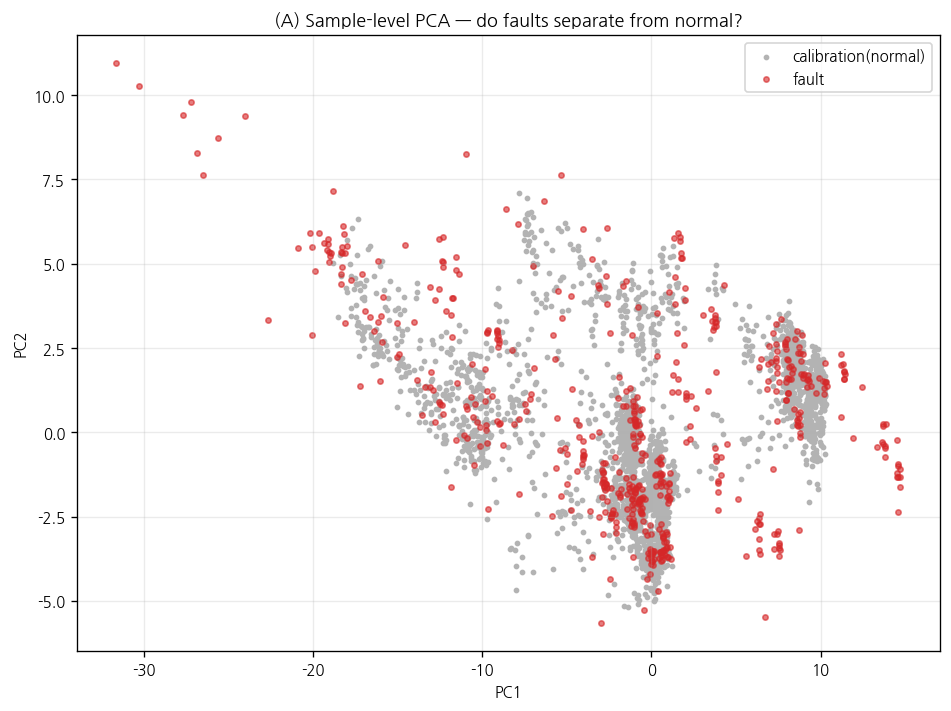

정상 누적분산 설명력 (PC1,PC2): [0.639 0.077]


In [21]:
from sklearn.decomposition import PCA

# 샘플(시점) 단위 빠른 확인: 정상 시점에 fit -> 전체 투영
samp = df.copy()
cal_mask = samp['fault_name']=='calibration'
mu, sd = samp.loc[cal_mask, sensor_cols].mean(), samp.loc[cal_mask, sensor_cols].std().replace(0,1)
Z = (samp[sensor_cols]-mu)/sd

pca = PCA(n_components=2).fit(Z[cal_mask])
sc = pca.transform(Z)

fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(sc[cal_mask,0], sc[cal_mask,1], s=6, c='0.7', label='calibration(normal)')
ax.scatter(sc[~cal_mask,0], sc[~cal_mask,1], s=10, c='#d62728', alpha=.6, label='fault')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.legend()
ax.set_title('(A) Sample-level PCA — do faults separate from normal?')
plt.tight_layout(); plt.show()
print("정상 누적분산 설명력 (PC1,PC2):", pca.explained_variance_ratio_.round(3))

In [22]:
# 각 센서가 정상 웨이퍼 안에서 시간에 따라 '매끄러운 신호'인지 '백색 노이즈'인지 판별
# 지표 = 웨이퍼 내 lag-1 자기상관(autocorr)
#   1에 가까움 -> 시간적으로 매끄러운 실제 신호 (정보 있음, 유지)
#   0에 가까움 -> 백색 노이즈 (autoscaling 시 증폭되어 해로움, 제거 후보)

def lag1_autocorr(x):
    x = x - x.mean()
    denom = (x**2).sum()
    return float((x[:-1]*x[1:]).sum()/denom) if denom > 0 else 0.0

ac = {}
for s in sensor_cols:
    cols = [f"{s}_t{k:02d}" for k in range(K)]
    ac[s] = np.mean([lag1_autocorr(X_df.loc[w, cols].values) for w in cal_idx])
ac = pd.Series(ac, name='autocorr').sort_values()

print("=== 자기상관 낮음 = 노이즈성 (제거 후보) Top 12 ===")
print(ac.head(12).round(3))
print("\n=== 자기상관 높음 = 신호성 (반드시 유지) Top 5 ===")
print(ac.tail(5).round(3))

=== 자기상관 낮음 = 노이즈성 (제거 후보) Top 12 ===
S2P2      0.073
S2P3      0.076
S2I5      0.278
S3I2      0.310
S34V5     0.336
S1I2      0.344
S1P3      0.369
S34PV1    0.370
S34PV5    0.370
S1I5      0.389
S2P4      0.412
S1V1      0.415
Name: autocorr, dtype: float64

=== 자기상관 높음 = 신호성 (반드시 유지) Top 5 ===
S1V5     0.869
S3V4     0.872
S3I4     0.874
S34I5    0.876
S3I5     0.877
Name: autocorr, dtype: float64


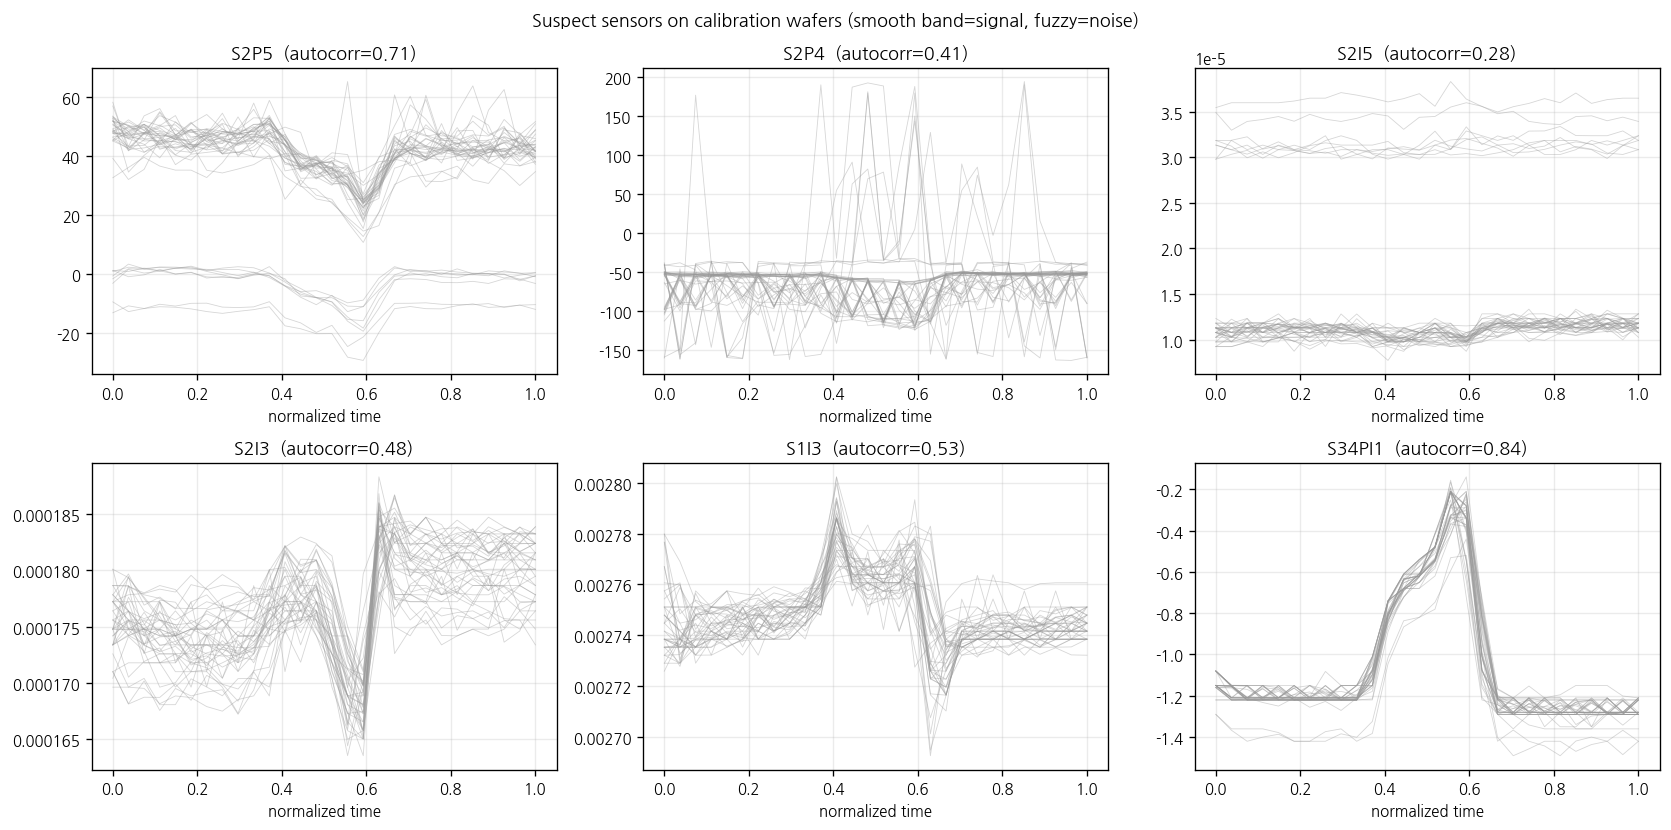

In [23]:
# 정상 웨이퍼 여러 장을 겹쳐 그림: 매끄러운 곡선 다발=신호 / 지저분한 띠=노이즈
check = ['S2P5', 'S2P4', 'S2I5', 'S2I3', 'S1I3', 'S34PI1']  # 의심 + 비교용(S1I3=판별력 높았던 신호)
tn = np.linspace(0, 1, K)
fig, axes = plt.subplots(2, 3, figsize=(14, 7)); axes = axes.ravel()
for i, s in enumerate(check):
    cols = [f"{s}_t{k:02d}" for k in range(K)]
    for w in cal_idx[:40]:
        axes[i].plot(tn, X_df.loc[w, cols].values, color='0.6', lw=.5, alpha=.4)
    axes[i].set_title(f"{s}  (autocorr={ac[s]:.2f})")
    axes[i].set_xlabel('normalized time')
fig.suptitle('Suspect sensors on calibration wafers (smooth band=signal, fuzzy=noise)')
plt.tight_layout(); plt.show()

In [24]:
cal_mean = X_df.loc[cal_idx].mean()
cal_std  = X_df.loc[cal_idx].std().replace(0, 1)
Xz = (X_df - cal_mean) / cal_std                       # 정상 기준 autoscale
fault_idx = label_s[label_s != 'calibration'].index

# 참고: 표준정규의 평균 |z| ≈ 0.80 -> 이상에서 0.8 = 정상과 구분 안 됨, 1.5↑ = 강한 신호
rows = []
for s in sensor_cols:
    cols = [f"{s}_t{k:02d}" for k in range(K)]
    fault_resp = Xz.loc[fault_idx, cols].abs().mean().mean()   # 이상에서 평균 |z|
    rows.append({'sensor': s, 'autocorr': round(ac[s], 3),
                 'fault_response': round(fault_resp, 3)})
decision = pd.DataFrame(rows).set_index('sensor')

decision['verdict'] = np.where(
    (decision['autocorr'] < 0.35) & (decision['fault_response'] < 1.0), '제거후보',
    np.where(decision['fault_response'] >= 1.5, '강한신호유지', '유지'))

print("=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===")
print(decision[decision['verdict']=='제거후보'].sort_values('fault_response'))
print("\n=== 노이즈처럼 보이지만 이상엔 반응 -> 살려야 함 ===")
print(decision[(decision['autocorr']<0.42) & (decision['fault_response']>=1.0)]
      .sort_values('fault_response', ascending=False).head(8))
print("\n요약:", decision['verdict'].value_counts().to_dict())

=== 제거후보 (정상=노이즈 + 이상에도 둔감) ===
        autocorr  fault_response verdict
sensor                                  
S2I5       0.278           0.955    제거후보
S2P2       0.073           0.973    제거후보
S2P3       0.076           0.980    제거후보

=== 노이즈처럼 보이지만 이상엔 반응 -> 살려야 함 ===
        autocorr  fault_response verdict
sensor                                  
S3I2       0.310          16.422  강한신호유지
S1V1       0.415           3.263  강한신호유지
S1I2       0.344           2.378  강한신호유지
S1P3       0.369           1.682  강한신호유지
S34PV1     0.370           1.172      유지
S34V5      0.336           1.157      유지

요약: {'유지': 56, '강한신호유지': 11, '제거후보': 3}


In [25]:
drop_sensors = ['S2I5', 'S2P2', 'S2P3']
keep_sensors = [s for s in sensor_cols if s not in drop_sensors]
keep_cols = [f"{s}_t{k:02d}" for s in keep_sensors for k in range(K)]

Xk  = X_df[keep_cols].copy()
mu_k = Xk.loc[cal_idx].mean()
sd_k = Xk.loc[cal_idx].std().replace(0, 1)
Xkz  = (Xk - mu_k) / sd_k                     # 정상 기준 autoscale

print(f"제거: {drop_sensors} -> 유지 {len(keep_sensors)}개 센서")
print(f"특징행렬: {Xkz.shape}  (웨이퍼 × (센서×시점))")

제거: ['S2I5', 'S2P2', 'S2P3'] -> 유지 67개 센서
특징행렬: (126, 1876)  (웨이퍼 × (센서×시점))


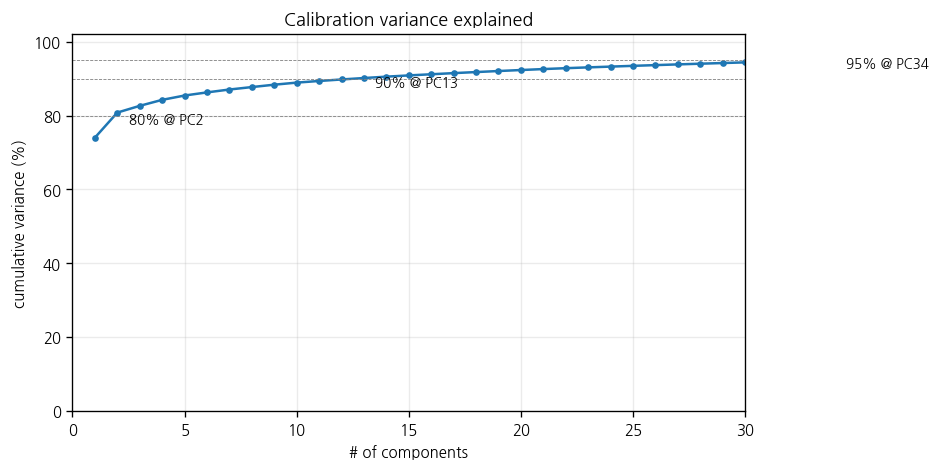

선택된 주성분 수 A = 13  (정상 분산 90% 설명)


In [26]:
from sklearn.decomposition import PCA

Xcal = Xkz.loc[cal_idx].values                # 정상 106장만
pca_full = PCA().fit(Xcal)
cum = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cum)+1), cum*100, 'o-', ms=3)
for thr in [80, 90, 95]:
    n = int(np.searchsorted(cum, thr/100)) + 1
    ax.axhline(thr, color='gray', ls='--', lw=.5)
    ax.text(n+0.5, thr-2, f"{thr}% @ PC{n}", fontsize=8)
ax.set_xlabel('# of components'); ax.set_ylabel('cumulative variance (%)')
ax.set_xlim(0, 30); ax.set_ylim(0, 102)
ax.set_title('Calibration variance explained')
plt.tight_layout(); plt.show()

A = int(np.searchsorted(cum, 0.90)) + 1       # 90% 자동 선택, 결과 보고 조정 가능
pca = PCA(n_components=A).fit(Xcal)
print(f"선택된 주성분 수 A = {A}  (정상 분산 90% 설명)")

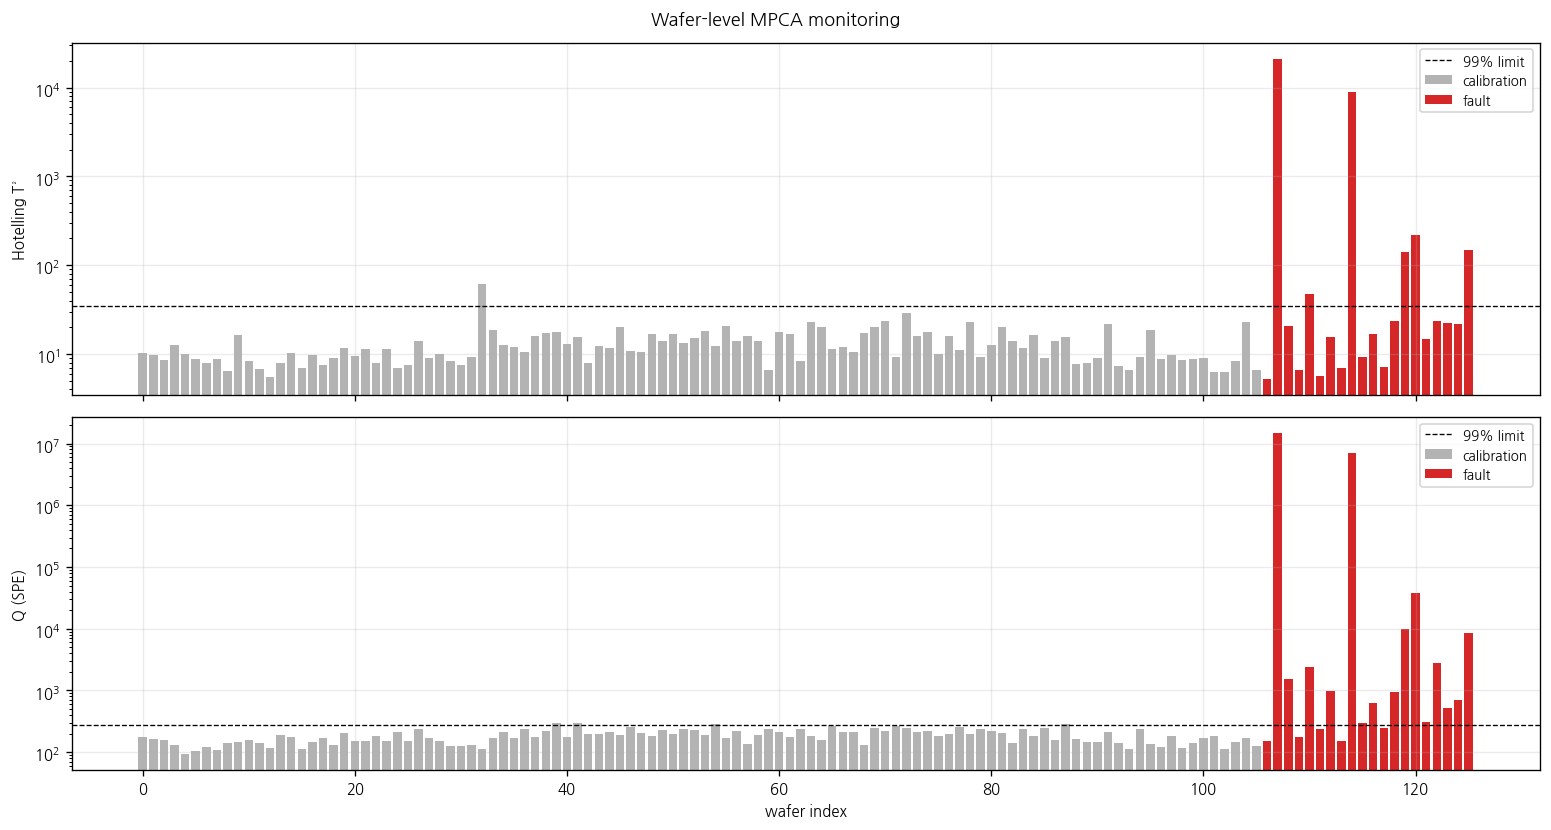

이상 20장 중 T² 탐지 6, Q 탐지 15, 둘 중 하나 15
정상 106장 중 오탐: T² 1, Q 4


In [27]:
from scipy import stats as st

# 모든 웨이퍼를 PCA 공간으로 투영
T     = pca.transform(Xkz.values)
Xrec  = pca.inverse_transform(T)
resid = Xkz.values - Xrec

lam = pca.explained_variance_
T2  = (T**2 / lam).sum(axis=1)                # Hotelling T² (모델 내)
Q   = (resid**2).sum(axis=1)                  # SPE / Q (모델 밖)

# 관리한계선 — Hotelling T² (F분포) + Q (Jackson-Mudholkar)
N = Xcal.shape[0]
T2_lim = (A*(N-1)*(N+1))/(N*(N-A)) * st.f.ppf(0.99, A, N-A)

eigs = pca_full.explained_variance_
th1, th2, th3 = eigs[A:].sum(), (eigs[A:]**2).sum(), (eigs[A:]**3).sum()
h0 = 1 - (2*th1*th3)/(3*th2**2) if th2 > 0 else 1
ca = st.norm.ppf(0.99)
Q_lim = th1 * ( (ca*np.sqrt(2*th2*h0**2)/th1) + 1 + th2*h0*(h0-1)/th1**2 )**(1/h0)

# 관리도 시각화
is_fault = (label_s != 'calibration').values
xs = np.arange(len(label_s))
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, val, lim, name in [(axes[0], T2, T2_lim, 'Hotelling T²'),
                           (axes[1], Q,  Q_lim,  'Q (SPE)')]:
    ax.bar(xs[~is_fault], val[~is_fault], color='0.7', label='calibration')
    ax.bar(xs[is_fault],  val[is_fault],  color='#d62728', label='fault')
    ax.axhline(lim, color='k', ls='--', lw=.8, label='99% limit')
    ax.set_ylabel(name); ax.legend(loc='upper right', fontsize=8); ax.set_yscale('log')
axes[1].set_xlabel('wafer index')
fig.suptitle('Wafer-level MPCA monitoring')
plt.tight_layout(); plt.show()

# 탐지 성능 요약
det_T2  = int((T2[is_fault] > T2_lim).sum())
det_Q   = int((Q [is_fault] > Q_lim ).sum())
det_any = int(((T2[is_fault] > T2_lim) | (Q[is_fault] > Q_lim)).sum())
fa_T2   = int((T2[~is_fault] > T2_lim).sum())
fa_Q    = int((Q [~is_fault] > Q_lim ).sum())
print(f"이상 {int(is_fault.sum())}장 중 T² 탐지 {det_T2}, Q 탐지 {det_Q}, 둘 중 하나 {det_any}")
print(f"정상 {int((~is_fault).sum())}장 중 오탐: T² {fa_T2}, Q {fa_Q}")

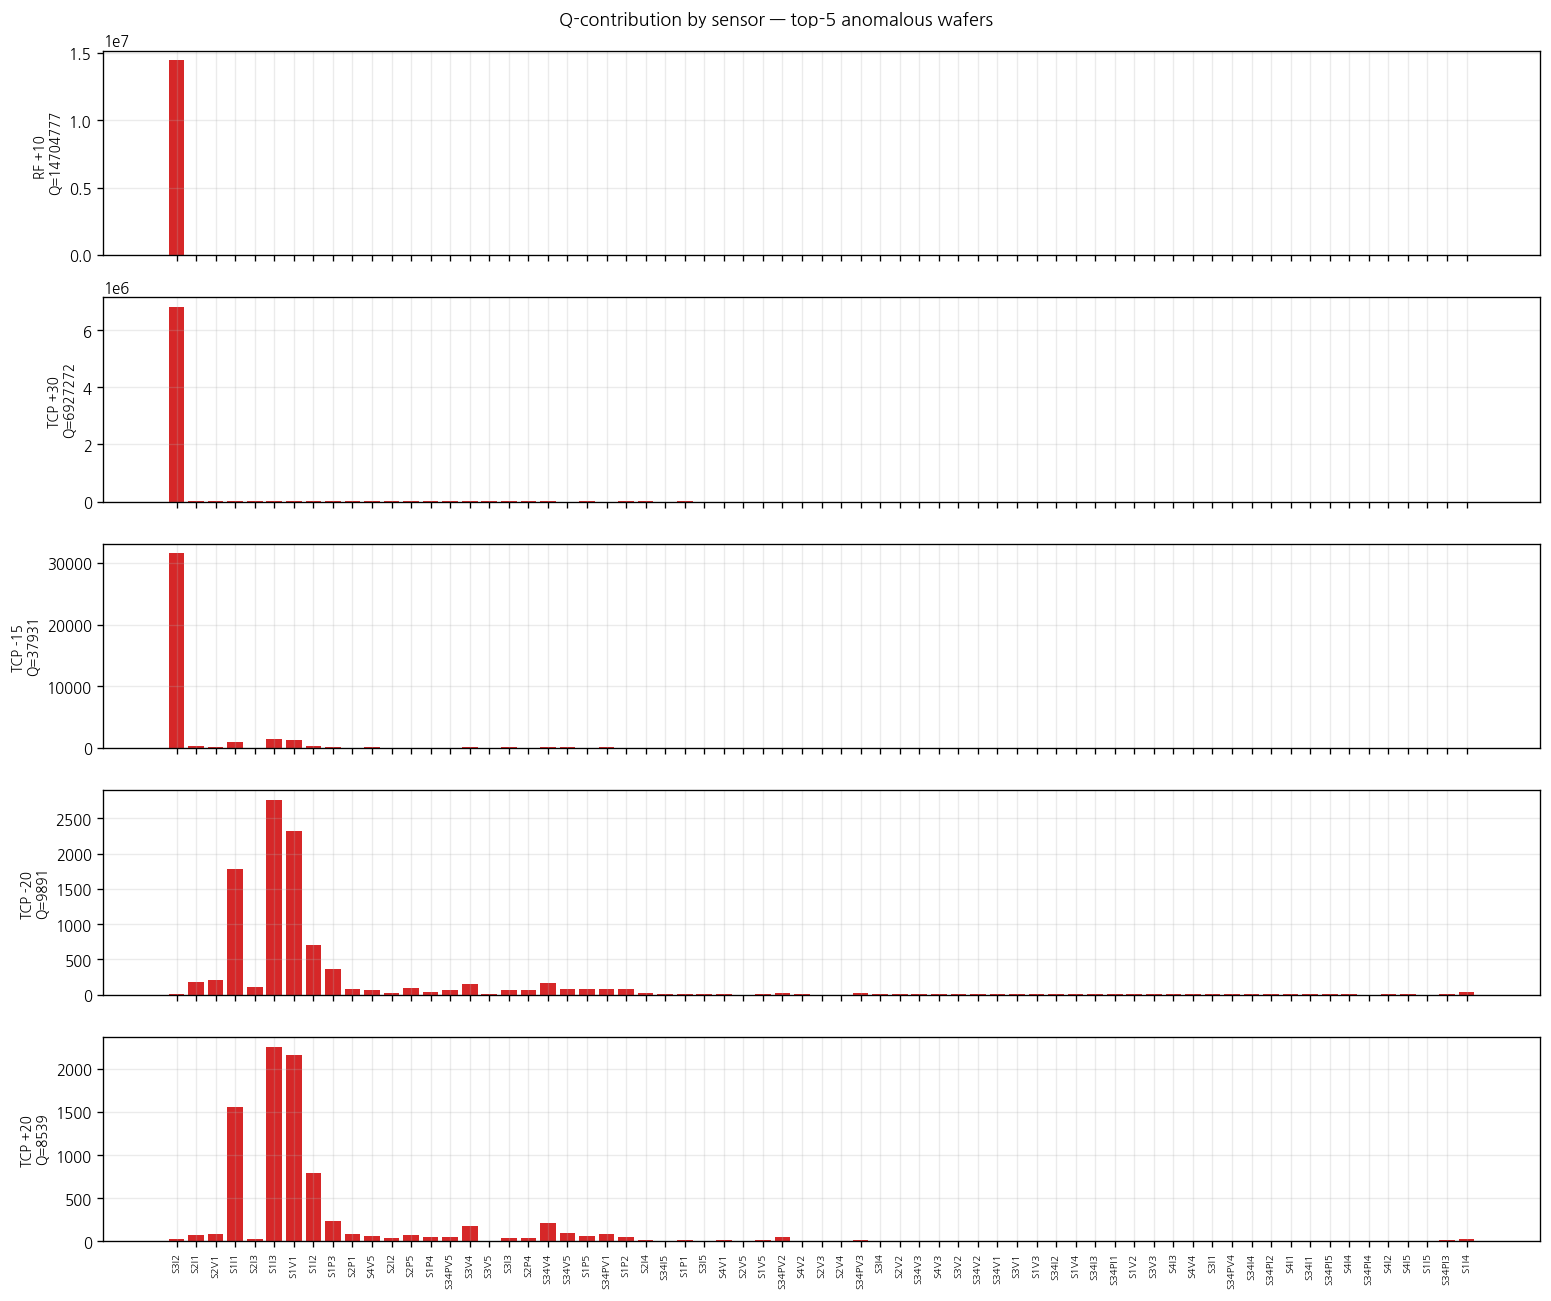

In [28]:
# Q 잔차를 센서별로 합산 -> 가장 튀는 이상 웨이퍼 5장의 센서별 기여도
fault_pos = np.where(is_fault)[0]
top5 = fault_pos[np.argsort(Q[fault_pos])[-5:][::-1]]

def sensor_contrib(row_resid):
    sq = pd.Series(row_resid**2, index=keep_cols)
    return sq.groupby(lambda c: c.rsplit('_t', 1)[0]).sum()

sens_order = sensor_contrib(resid[top5[0]]).sort_values(ascending=False).index

fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True)
for ax, i in zip(axes, top5):
    c = sensor_contrib(resid[i]).reindex(sens_order).fillna(0)
    ax.bar(range(len(c)), c.values, color='#d62728')
    ax.set_ylabel(f"{label_s.iloc[i]}\nQ={Q[i]:.0f}", fontsize=8)
axes[-1].set_xticks(range(len(sens_order)))
axes[-1].set_xticklabels(sens_order, rotation=90, fontsize=6)
fig.suptitle('Q-contribution by sensor — top-5 anomalous wafers')
plt.tight_layout(); plt.show()

=== 이상 웨이퍼별 탐지 결과 (Q 큰 순) ===
   fault       T2           Q  any_th  any_emp
RF +10   21200.95 14704776.62    True     True
TCP +30   8991.43  6927272.16    True     True
TCP -15    218.93    37930.73    True     True
TCP -20    142.33     9890.53    True     True
TCP +20    147.06     8539.42    True     True
RF -12      23.70     2796.41    True     True
BCl3 +5     47.05     2397.52    True     True
Pr +3       20.56     1509.41    True     True
Cl2 -5      15.38      968.71    True     True
Pr +2       23.71      941.88    True     True
Pr +1       21.92      700.35    True     True
RF +8       17.00      636.69    True     True
BCl3 +10    22.35      515.99    True     True
Cl2 -10     14.82      308.20    True     True
Cl2 +5       9.22      293.02    True    False
BCl3 -5      7.20      244.12   False    False
Pr -2        5.69      239.59   False    False
TCP +10      6.63      175.75   False    False
He Chuck     7.01      153.22   False    False
TCP +50      5.22      151.16 

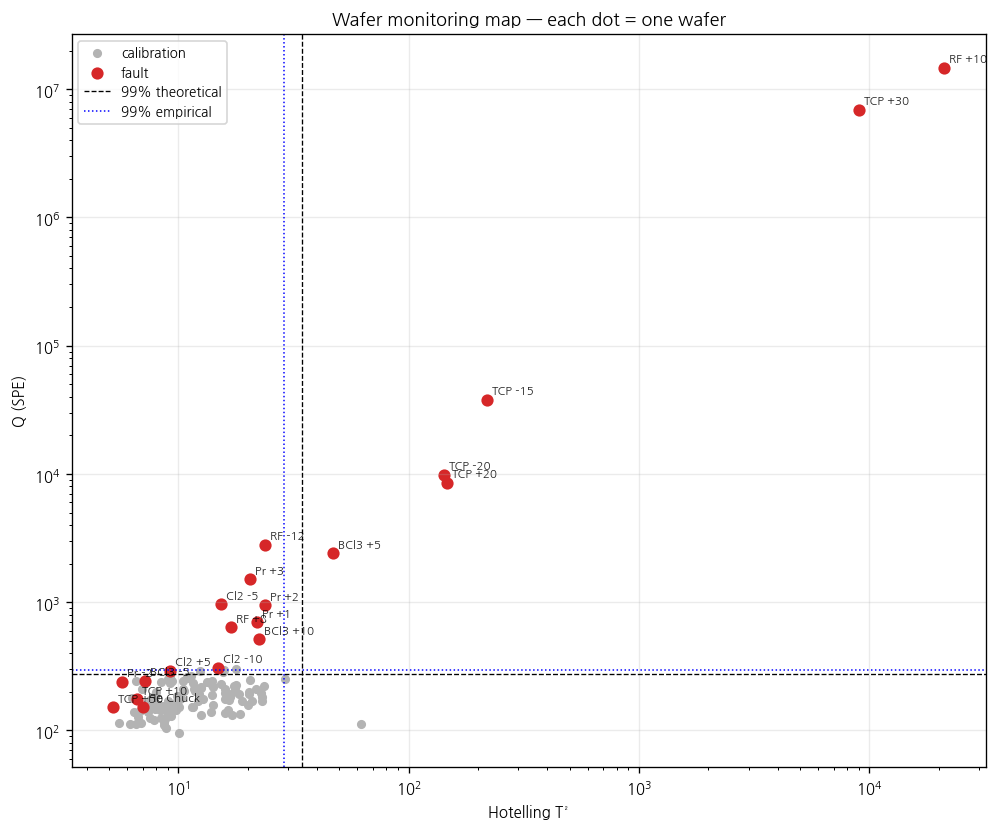

In [29]:
# 경험적 한계선: 정상 분포 99% 분위수
T2_lim_emp = np.quantile(T2[~is_fault], 0.99)
Q_lim_emp  = np.quantile(Q[~is_fault],  0.99)

# 이상 웨이퍼별 표
res_df = pd.DataFrame({
    'fault': label_s.values, 'T2': T2, 'Q': Q,
    'T2_th':  T2 > T2_lim,     'Q_th':  Q > Q_lim,
    'T2_emp': T2 > T2_lim_emp, 'Q_emp': Q > Q_lim_emp,
})
ft = res_df[res_df['fault'] != 'calibration'].copy()
ft['any_th']  = ft['T2_th']  | ft['Q_th']
ft['any_emp'] = ft['T2_emp'] | ft['Q_emp']
print("=== 이상 웨이퍼별 탐지 결과 (Q 큰 순) ===")
print(ft.sort_values('Q', ascending=False)[['fault','T2','Q','any_th','any_emp']]
      .round(2).to_string(index=False))

cal_th  = res_df.loc[res_df.fault=='calibration', ['T2_th','Q_th']].any(axis=1).sum()
cal_emp = res_df.loc[res_df.fault=='calibration', ['T2_emp','Q_emp']].any(axis=1).sum()
print(f"\n이론 한계: T²>{T2_lim:.1f}, Q>{Q_lim:.1f}  -> 탐지 {ft['any_th'].sum()}/20, 오탐 {cal_th}/106")
print(f"경험 한계: T²>{T2_lim_emp:.1f}, Q>{Q_lim_emp:.1f}  -> 탐지 {ft['any_emp'].sum()}/20, 오탐 {cal_emp}/106")

# T²–Q 산점도 (MSPC 표준 뷰)
fig, ax = plt.subplots(figsize=(8.5, 7))
ax.scatter(T2[~is_fault], Q[~is_fault], s=20, c='0.7', label='calibration')
ax.scatter(T2[is_fault],  Q[is_fault],  s=40, c='#d62728', label='fault')
for i in np.where(is_fault)[0]:
    ax.annotate(label_s.iloc[i], (T2[i], Q[i]), fontsize=7,
                xytext=(3,3), textcoords='offset points', alpha=.85)
ax.axvline(T2_lim,     color='k', ls='--', lw=.8, label='99% theoretical')
ax.axhline(Q_lim,      color='k', ls='--', lw=.8)
ax.axvline(T2_lim_emp, color='b', ls=':',  lw=.9, label='99% empirical')
ax.axhline(Q_lim_emp,  color='b', ls=':',  lw=.9)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Hotelling T²'); ax.set_ylabel('Q (SPE)')
ax.set_title('Wafer monitoring map — each dot = one wafer')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

In [30]:
ablation = []
for A_try in [2, 5, 7, 10, 13, 20, 30]:
    p_ = PCA(n_components=A_try).fit(Xcal)
    Tt = p_.transform(Xkz.values)
    res_ = Xkz.values - p_.inverse_transform(Tt)
    T2_ = (Tt**2 / p_.explained_variance_).sum(axis=1)
    Q_  = (res_**2).sum(axis=1)
    T2L = np.quantile(T2_[~is_fault], 0.99)
    QL  = np.quantile(Q_[~is_fault],  0.99)
    hit_T2, hit_Q = (T2_>T2L), (Q_>QL)
    any_hit = hit_T2 | hit_Q
    ablation.append({
        'A': A_try,
        'cum_var%': round(p_.explained_variance_ratio_.sum()*100, 1),
        '탐지': f"{any_hit[is_fault].sum()}/20",
        '오탐': f"{any_hit[~is_fault].sum()}/106",
        'T2탐지': int(hit_T2[is_fault].sum()),
        'Q탐지':  int(hit_Q[is_fault].sum()),
    })
print("=== A 민감도 (오탐 1% 고정 기준) ===")
print(pd.DataFrame(ablation).to_string(index=False))

=== A 민감도 (오탐 1% 고정 기준) ===
 A  cum_var%    탐지    오탐  T2탐지  Q탐지
 2      80.8 13/20 4/106     4   13
 5      85.4 13/20 4/106     5   13
 7      87.1 13/20 3/106     5   13
10      88.9 13/20 4/106     5   13
13      90.2 14/20 4/106     6   14
20      92.3 15/20 4/106     6   15
30      94.4 17/20 4/106     6   17


In [31]:
A_final = 20
pca_final = PCA(n_components=A_final).fit(Xcal)

T_final   = pca_final.transform(Xkz.values)
res_final = Xkz.values - pca_final.inverse_transform(T_final)
T2_final  = (T_final**2 / pca_final.explained_variance_).sum(axis=1)
Q_final   = (res_final**2).sum(axis=1)

T2_lim_f = np.quantile(T2_final[~is_fault], 0.99)
Q_lim_f  = np.quantile(Q_final [~is_fault], 0.99)
hit = (T2_final > T2_lim_f) | (Q_final > Q_lim_f)

print(f"[최종 A={A_final}, 정상 분산 {pca_final.explained_variance_ratio_.sum()*100:.1f}% 설명]")
print(f"경험적 99% 한계선: T² > {T2_lim_f:.2f},  Q > {Q_lim_f:.2f}")
print(f"탐지 {hit[is_fault].sum()}/20  |  정상 오탐 {hit[~is_fault].sum()}/106")
print("놓친 fault:", label_s[is_fault].values[~hit[is_fault]].tolist())

# 산출물 1: 융합용 RFM 특징행렬 (웨이퍼명 × (센서×시점), 정상기준 autoscale)
#  -> 나중에 OES/EV의 같은 형식 행렬과 웨이퍼명 기준 가로 결합
Xkz.to_csv('rfm_block_features.csv')

# 산출물 2: 웨이퍼별 모니터링 스코어 (앙상블/메타모델용)
scores = pd.DataFrame({
    'fault_name': label_s.values,
    'T2_rfm': T2_final, 'Q_rfm': Q_final, 'hit_rfm': hit,
}, index=label_s.index)
scores.index.name = 'wafer_names'
scores.to_csv('rfm_block_scores.csv')

# 다운로드
from google.colab import files
files.download('rfm_block_features.csv')
files.download('rfm_block_scores.csv')

[최종 A=20, 정상 분산 92.3% 설명]
경험적 99% 한계선: T² > 51.22,  Q > 217.45
탐지 16/20  |  정상 오탐 4/106
놓친 fault: ['TCP +50 ', 'TCP +10 ', 'Pr -2   ', 'He Chuck']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>